In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

The new directory is created!


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

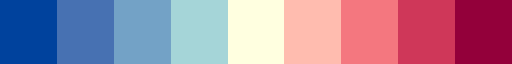

In [3]:
my_cmap

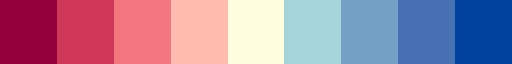

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [7]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

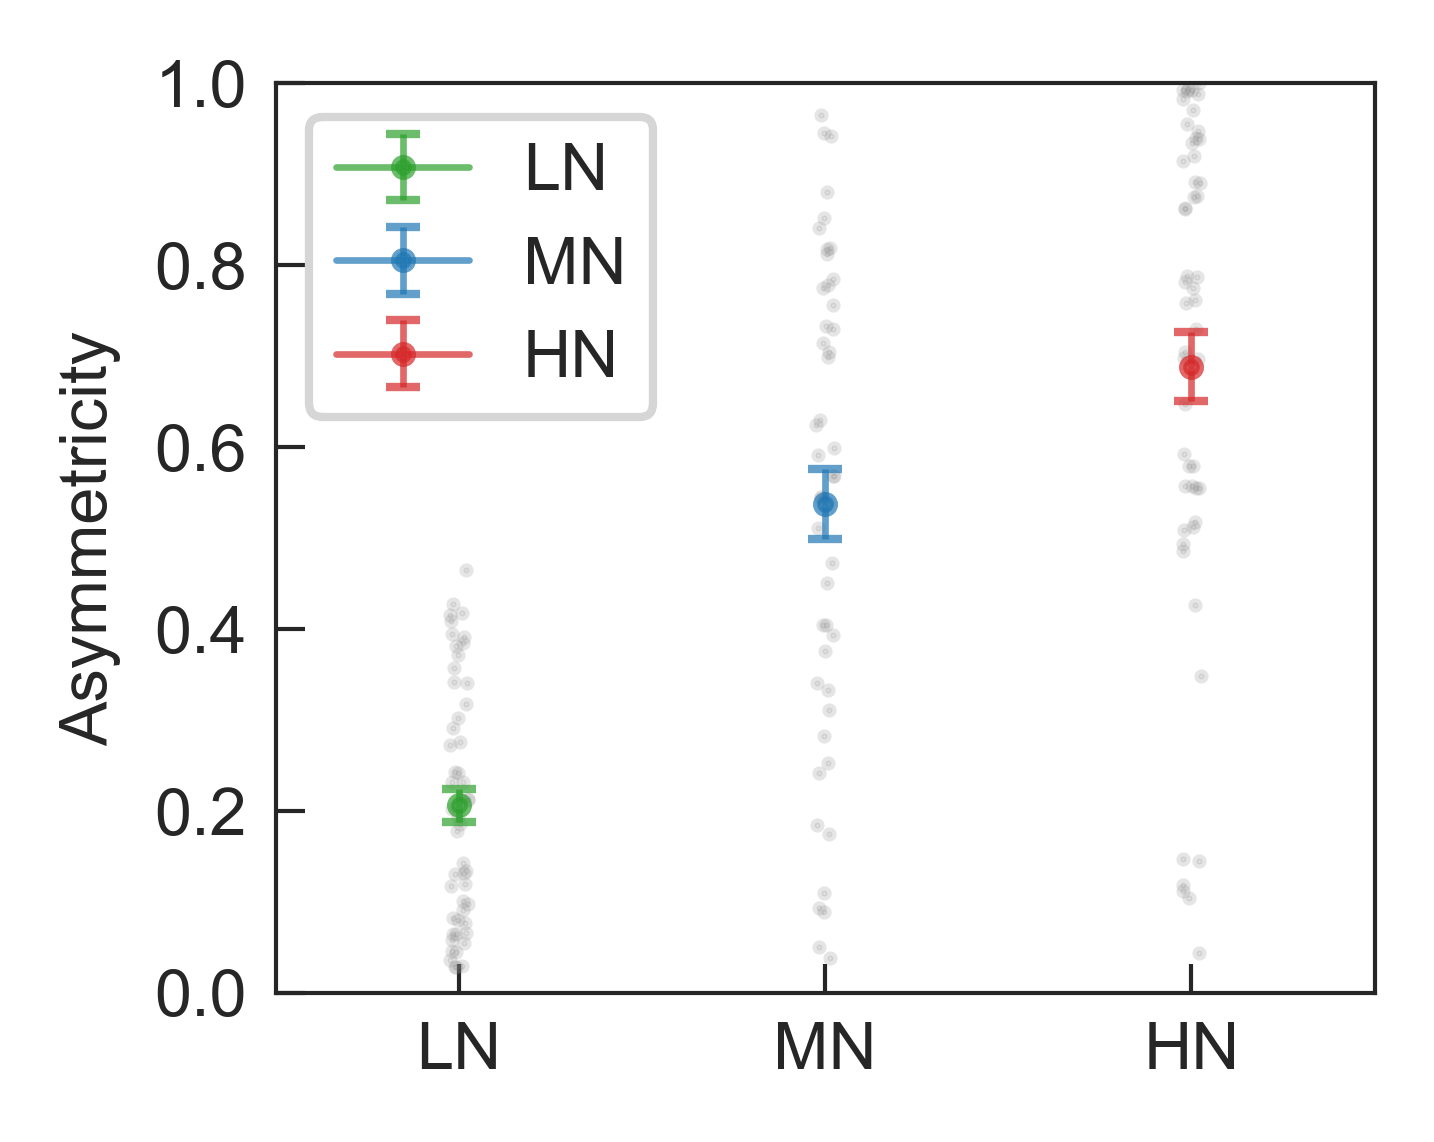

In [8]:
## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
Variable2plot_list=[
       'Assymetricity_BC_5']


for Variable2plot in Variable2plot_list:
    Name2show = Variable2plot
    
    IDX_list = Syn_Coal_IDX["LN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data1=data
    
    IDX_list = Syn_Coal_IDX["MN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data2=data
    
    IDX_list = Syn_Coal_IDX["HN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data3 = data
    
    f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')

    for ii, data in enumerate([data1, data2, data3]):
        plot_x=([[0,1,2][ii]])*len(data)+(np.random.rand(len(data))-0.5)*0.05
        plot_y=data
        plt.scatter(plot_x, plot_y, color="grey", s=0.5,  alpha=0.2)
            #plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
            #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        #    colors=['grey','red','blue']

        #colorcoding=0
        #if plot_y[0]<plot_y[1]:
        #    colorcoding=2
        #plt.plot(plot_x,plot_y, linewidth=0.2, color=colors[colorcoding],alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    
    
    mean_x=[0,1,2]
    mean_y=[np.mean(data1), np.mean(data2), np.mean(data3)]
    sem=[np.sqrt(np.var((data1))/len(data1)),np.sqrt(np.var(data2)/len(data2)),np.sqrt(np.var(data3)/len(data3))]
    colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]
    labels=['LN','MN','HN']
    for i in range(3):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', alpha=.7, markersize=2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    #plt.plot(mean_x,mean_y,linestyle='-', linewidth=.6,alpha=0.9, color='black' )

    # Set plot limits and labels
    plt.xlim(-.5, 2.5)
    plt.ylim(0, 1)
    plt.ylabel('Asymmetricity')
    plt.xticks([0,1,2], ['LN','MN','HN'])
    plt.legend()
    f.savefig('Figure/Fig_3-1_DistributionOfAssymetiricty_LNMNHN_style2.svg',bbox_inches='tight')

    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])

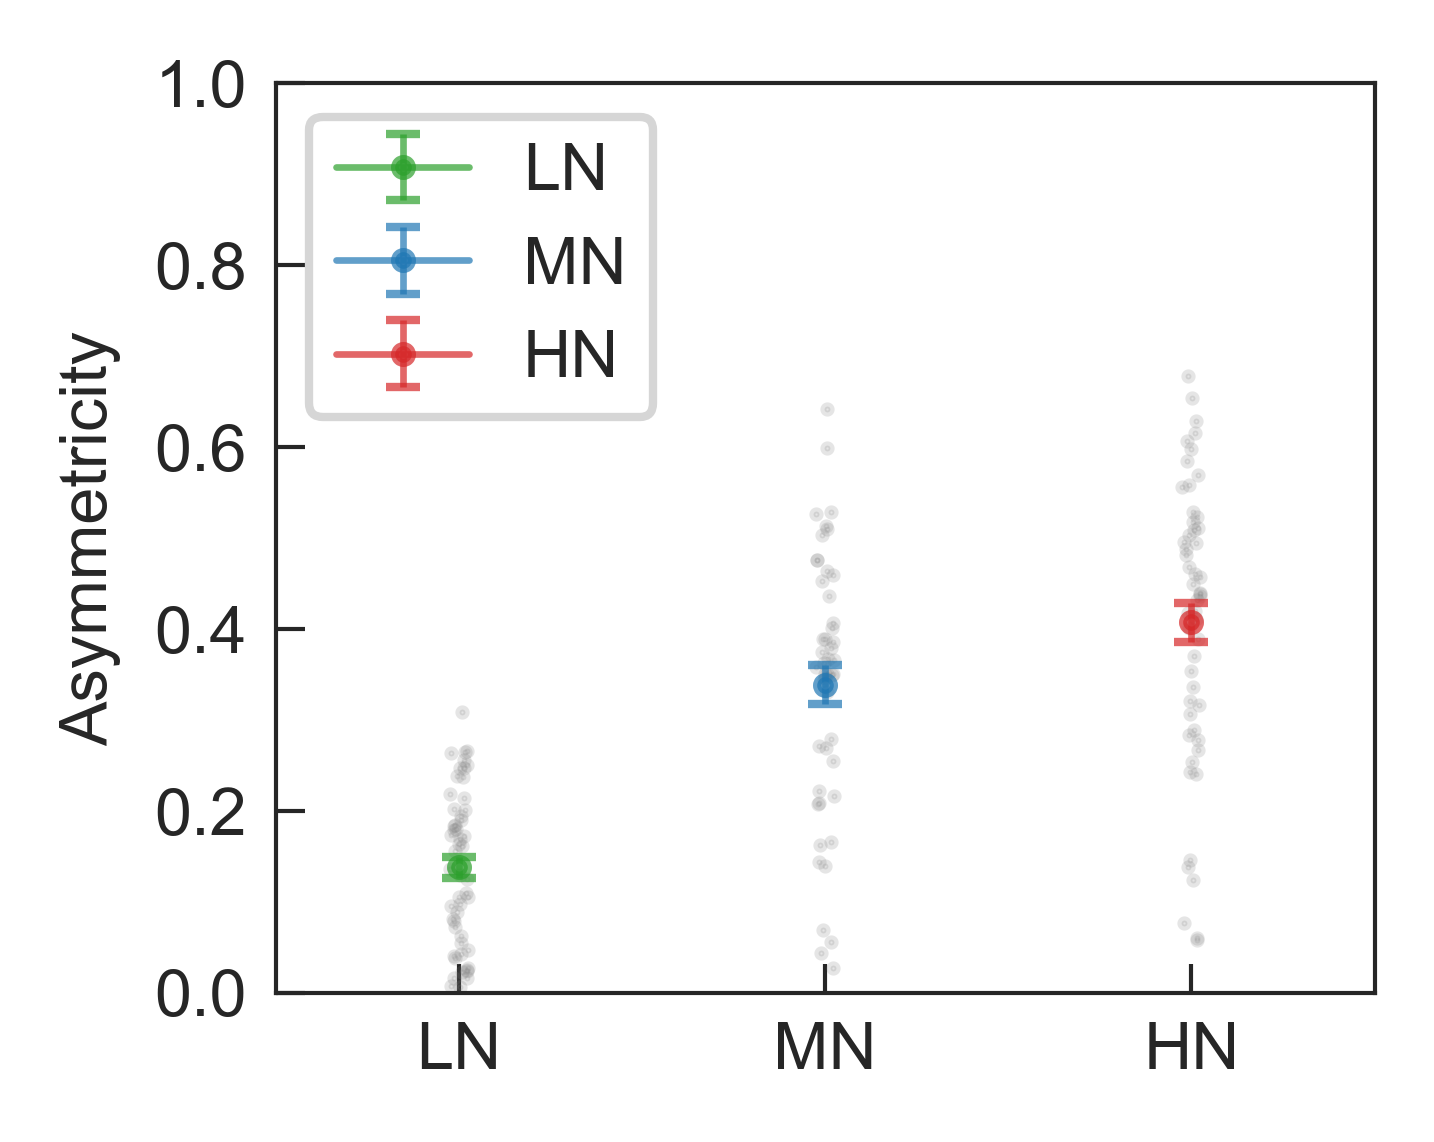

In [9]:
## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
Variable2plot_list=[
       'Assymetricity_JS_5']


for Variable2plot in Variable2plot_list:
    Name2show = Variable2plot
    
    IDX_list = Syn_Coal_IDX["LN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data1=data
    
    IDX_list = Syn_Coal_IDX["MN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data2=data
    
    IDX_list = Syn_Coal_IDX["HN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data3 = data
    
    f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')

    for ii, data in enumerate([data1, data2, data3]):
        plot_x=([[0,1,2][ii]])*len(data)+(np.random.rand(len(data))-0.5)*0.05
        plot_y=data
        plt.scatter(plot_x, plot_y, color="grey", s=0.5,  alpha=0.2)
            #plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
            #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        #    colors=['grey','red','blue']

        #colorcoding=0
        #if plot_y[0]<plot_y[1]:
        #    colorcoding=2
        #plt.plot(plot_x,plot_y, linewidth=0.2, color=colors[colorcoding],alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    
    
    mean_x=[0,1,2]
    mean_y=[np.mean(data1), np.mean(data2), np.mean(data3)]
    sem=[np.sqrt(np.var((data1))/len(data1)),np.sqrt(np.var(data2)/len(data2)),np.sqrt(np.var(data3)/len(data3))]
    colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]
    labels=['LN','MN','HN']
    for i in range(3):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', alpha=.7, markersize=2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    #plt.plot(mean_x,mean_y,linestyle='-', linewidth=.6,alpha=0.9, color='black' )

    # Set plot limits and labels
    plt.xlim(-.5, 2.5)
    plt.ylim(0, 1)
    plt.ylabel('Asymmetricity')
    plt.xticks([0,1,2], ['LN','MN','HN'])
    plt.legend()
    f.savefig('Figure/Fig_3-1_DistributionOfAssymetiricty_LNMNHN_style2.svg',bbox_inches='tight')

    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])

0.4807692307692308
0.7307692307692307


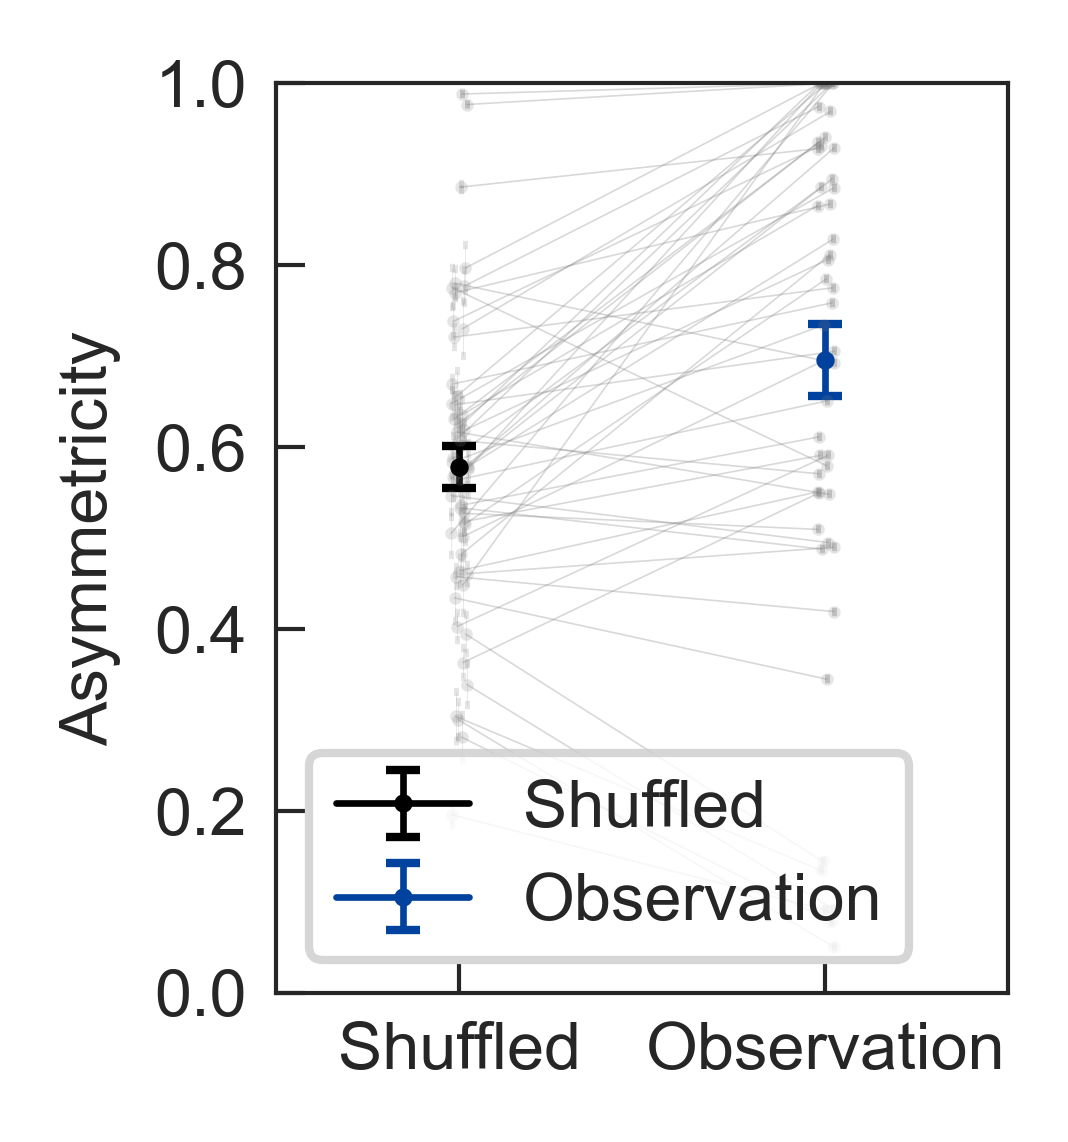

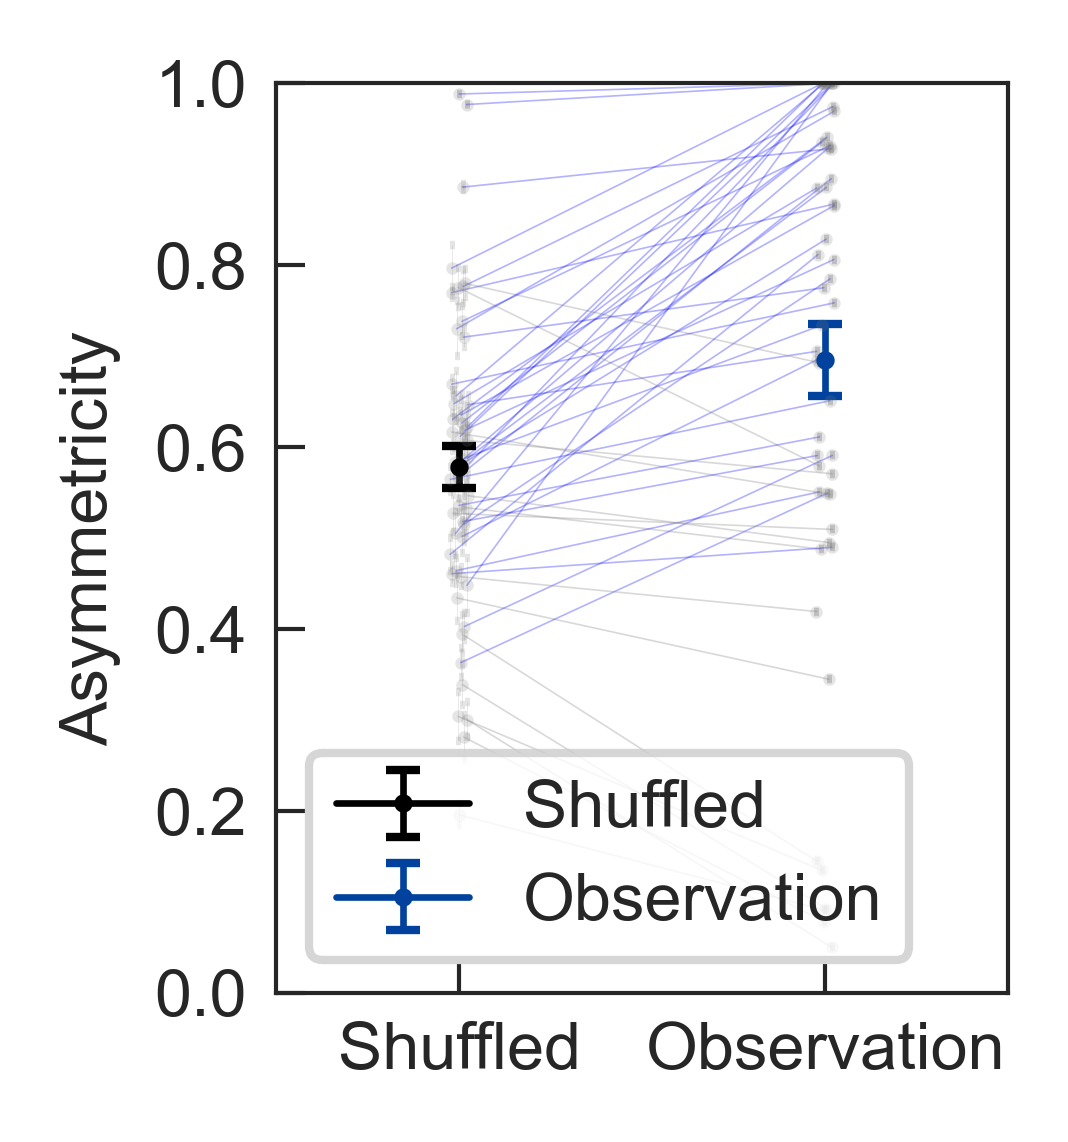

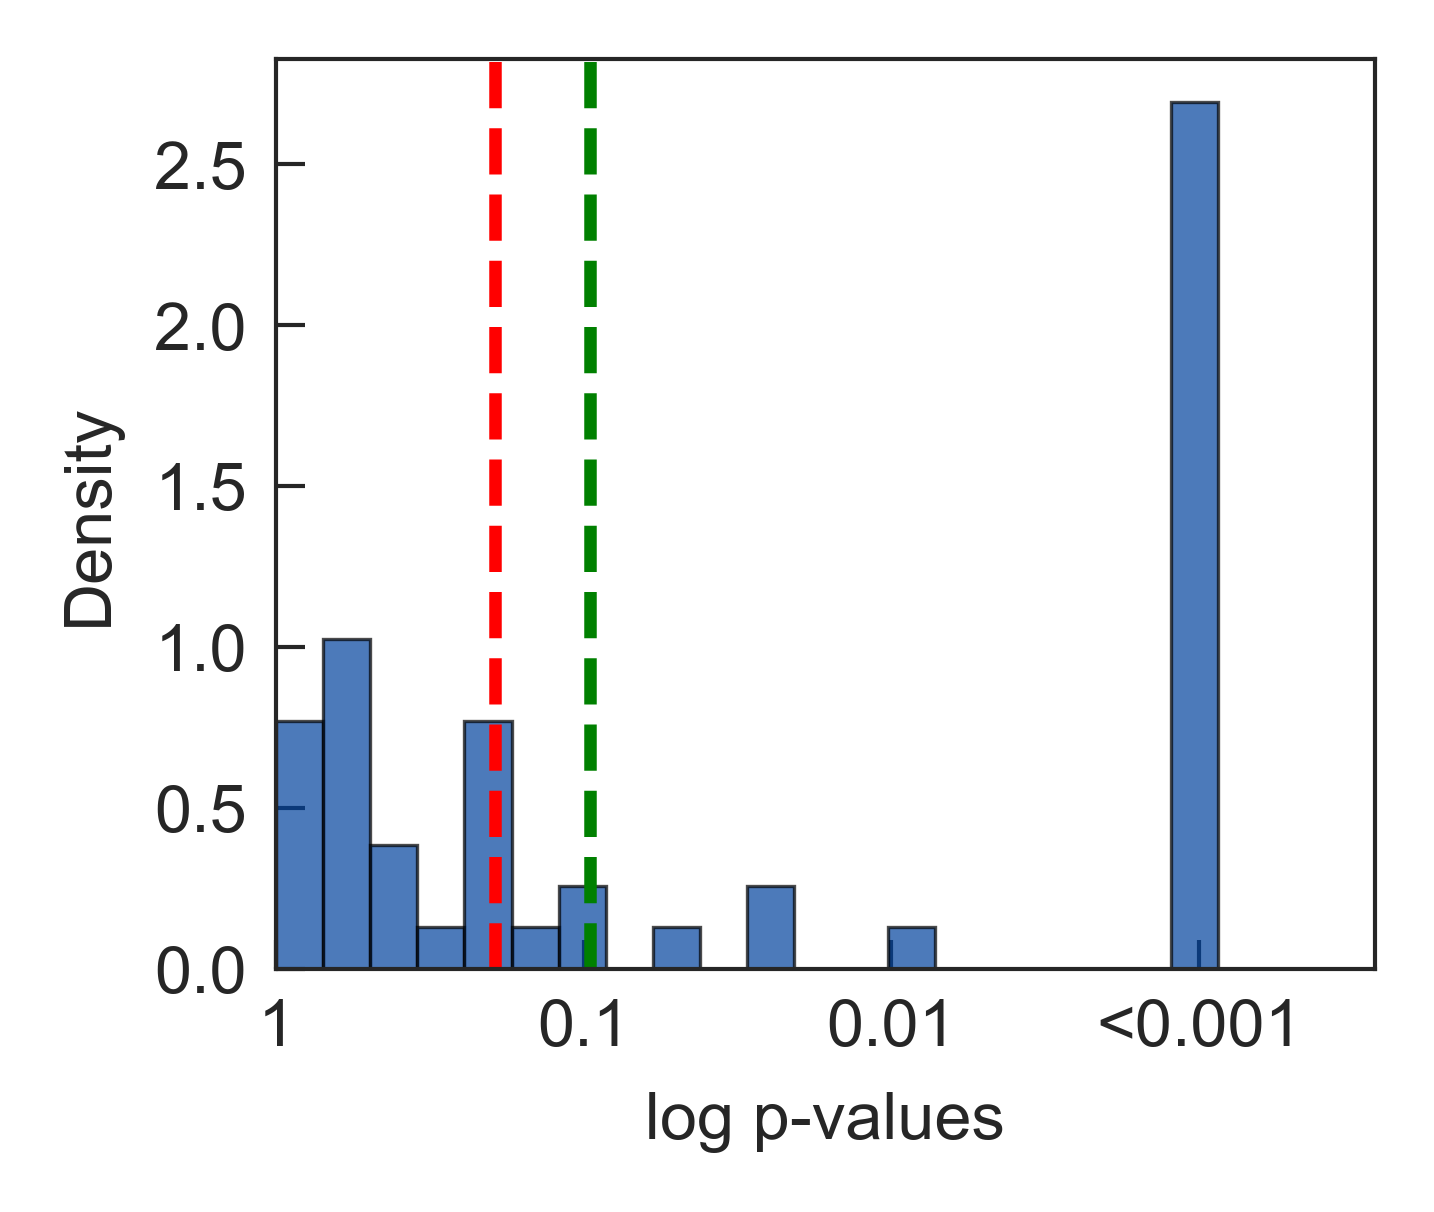

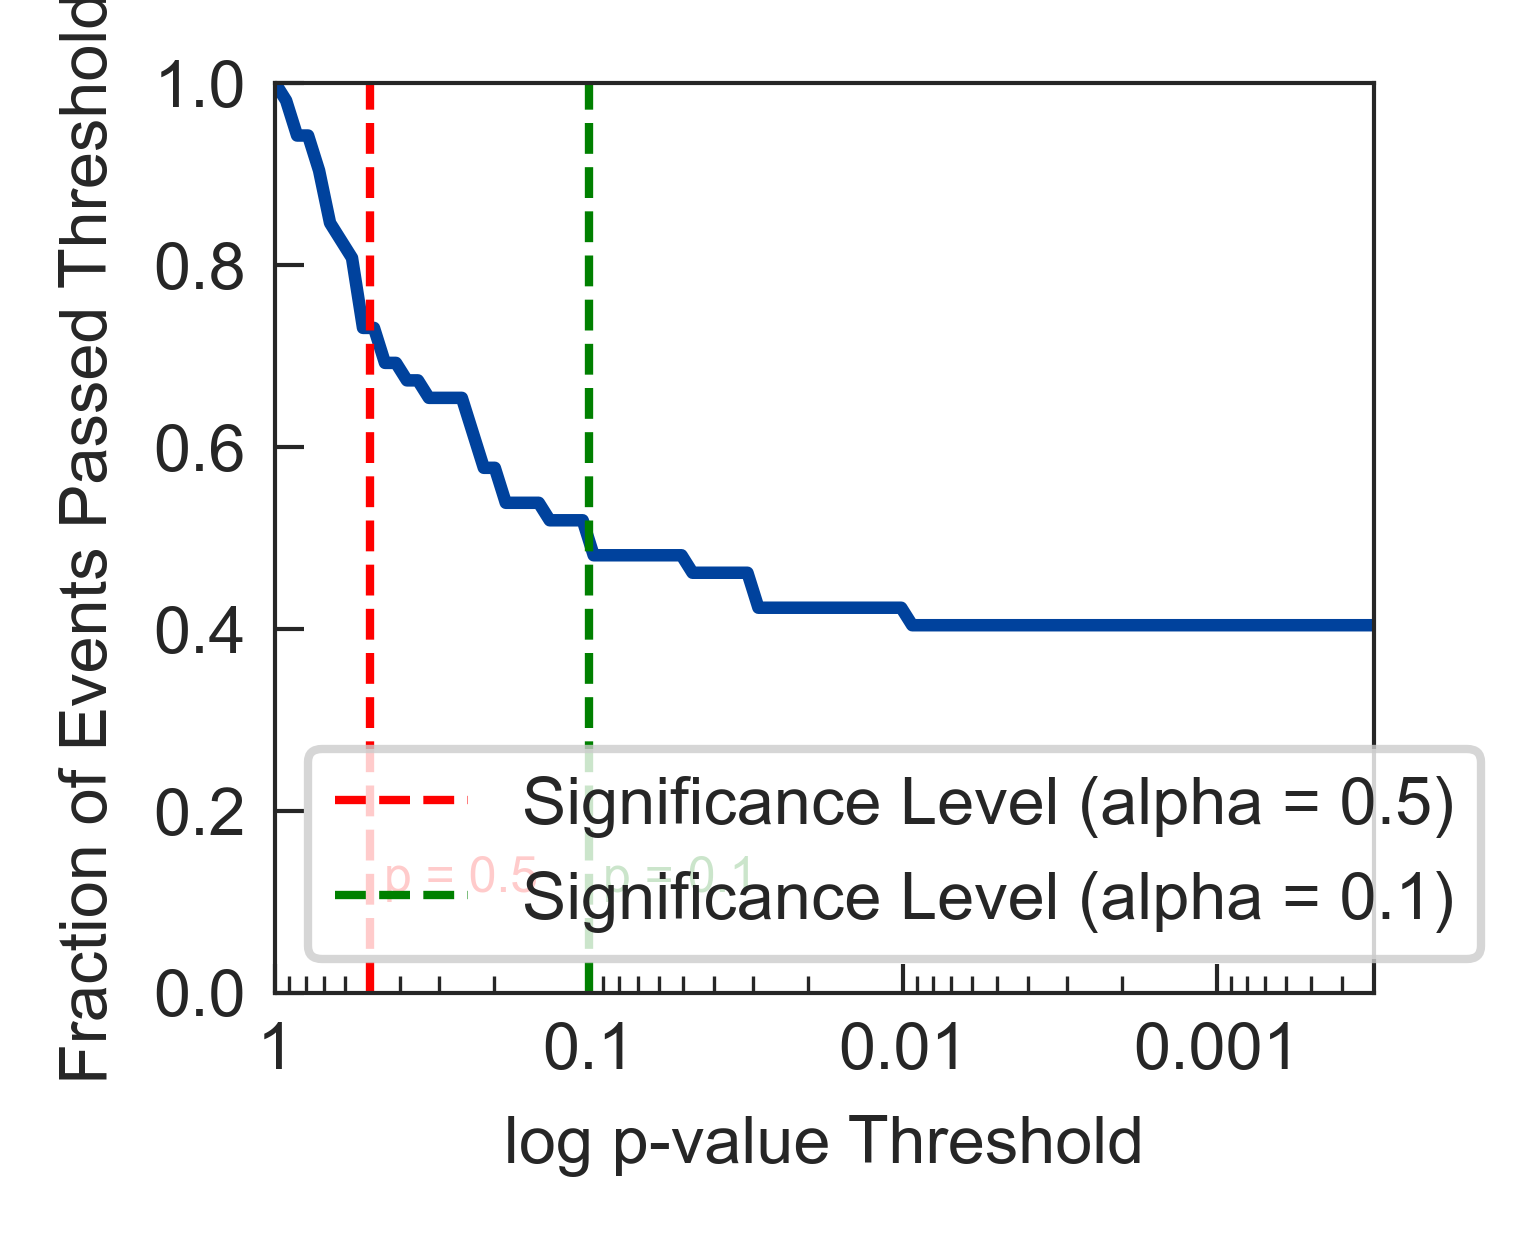

In [19]:
Null_model_rep=100




    #sns.kdeplot(data, shade=True,bw_adjust=.6)

type_name='HN_12'
threshold=1e-4
degList=np.zeros(43)

if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    Variable2plot=Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data['Assymetricity_BC_3']

if True:
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(Null_model_rep):
            c_mix=np.array(Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:])
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))
            #F1=SimilarityJS(moc_c1, c_mix, threshold)
            #F2=SimilarityJS(moc_c2, c_mix, threshold)
            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    
    data_null_model = np.array(data_null_model)
    data_null_model = data_null_model.reshape([-1,Null_model_rep])
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

    
    data1=data_null_model
    data2=data.values

    #combined_data = np.concatenate([data1, data2])
    #labels = ['Null model'] * len(data1) + ['Observation'] * len(data2)
    #df = pd.DataFrame({'Value': combined_data, 'Data': labels})
    
    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        plt.plot(plot_x,plot_y, linewidth=0.2, color='grey',alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Asymmetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig('Figure/Fig_3-5_DistributionOfAssymetiricty_boxplot_style1_'+type_name+'.svg',bbox_inches='tight')
    
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    ##Version2
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        
        colorcoding=0
        if plot_y[0]<plot_y[1]:
            colorcoding=2
        plt.plot(plot_x,plot_y, linewidth=0.2, color=colors[colorcoding],alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Asymmetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig('Figure/Fig_3-5_DistributionOfAssymetiricty_boxplot_style2_'+type_name+'.svg',bbox_inches='tight')

    from scipy.stats import norm
p_list=[]
p_list2=[]
for i in range(data1.shape[0]):
    obs=data2[i]
    null_y=data1[i,:]
    # Single sample data point
    sample_data = obs

    # Null hypothesis mean (B) and null hypothesis variance
    null_mean = 0
    null_variance = np.sum(null_y**2-0)/len(null_y) # Replace with your actual null variance
    
    # Calculate the Z-score
    z_score = (sample_data - null_mean) / np.sqrt(null_variance)

    # Calculate the two-tailed p-value
    p_value = (1 - norm.cdf(np.abs(z_score)))

    p_list.append(p_value)
    p_list2.append(np.mean(null_y>obs))

    
    
    
    
f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
p_list2=np.array(p_list2)


range_n=3
bin_edges = np.linspace(start=0, stop=range_n, num=21)  # Adjust as needed

plt.hist(-np.log10(p_list2+10**(-range_n)),bins=bin_edges,color=my_cmap(0), alpha=0.7, linewidth=0.4, edgecolor='black', density=True)
plt.gca().invert_xaxis()

plt.axvline(-np.log10(0.2), color='red', linestyle='--', label='p=0.05')
plt.axvline(-np.log10(0.1), color='green', linestyle='--', label='p=0.1')

plt.xlim(0, range_n+0.5)

# Set x-axis tick labels as 10^(-n)
plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().set_xticks([n*0.98 for n in range(range_n+1)])  # Tick positions
plt.gca().set_xticklabels(['1', '0.1', '0.01']+['<0.001'])  # Tick labels
#plt.grid()

plt.xlabel('log p-values')
plt.ylabel('Density')
f.savefig('Figure/Fig_3-5_DistributionOfPval_histogram_'+type_name+'.svg',bbox_inches='tight')

print(np.mean(p_list2<0.1))
print(np.mean(p_list2<0.5))



f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
# Sample p-values (replace with your actual p-values)
p_values = p_list2

# Create an array of logarithmically spaced p-value thresholds
thresholds = np.logspace(-3.5, 0, 101)  # Adjust the range and number of thresholds as needed

# Calculate the fraction of samples passing each threshold
pass_fraction = [np.mean(np.array(p_values) <= threshold) for threshold in thresholds]

# Create a plot with logarithmic scales
plt.semilogx(thresholds, pass_fraction, linestyle='-', color=my_cmap(0))

# Highlight the significance level (e.g., alpha = 0.05)
alpha = 0.5
plt.axvline(alpha, linestyle='--', linewidth=1, color='red', label=f'Significance Level (alpha = {alpha})')
plt.text(alpha*0.90, 0.1, f'p = {alpha}', fontsize=6, color='red', verticalalignment='bottom')

alpha = 0.1

plt.axvline(alpha, linestyle='--', linewidth=1, color='green', label=f'Significance Level (alpha = {alpha})')
plt.text(alpha*0.90, 0.1, f'p = {alpha}', fontsize=6, color='green', verticalalignment='bottom')

plt.ylim(0,1)
plt.xlim(10**(-range_n-0.5),10**0, )
plt.gca().invert_xaxis()

# Set plot labels and legend
plt.xlabel('log p-value Threshold')
plt.ylabel('Fraction of Events Passed Threshold')
plt.legend()
f.savefig('Figure/Fig_3-5_DistributionOfPval_accumulated_'+type_name+'.svg',bbox_inches='tight')

plt.gca().set_xticks([1, 0.1, 0.01, 0.001])  # Tick positions
plt.gca().set_xticklabels(['1', '0.1', '0.01']+['0.001'])  # Tick labels

# Show the plot
plt.show()

    

In [ ]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data

Null_model_rep=1000

if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot=Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data['Assymetricity_BC_3']



    #sns.kdeplot(data, shade=True,bw_adjust=.6)


if True:
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(Null_model_rep):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    
    data_null_model = np.array(data_null_model)
    data_null_model = data_null_model.reshape([-1,Null_model_rep])
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

    
    data1=data_null_model
    data2=data.values

    #combined_data = np.concatenate([data1, data2])
    #labels = ['Null model'] * len(data1) + ['Observation'] * len(data2)
    #df = pd.DataFrame({'Value': combined_data, 'Data': labels})
    
    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        plt.plot(plot_x,plot_y, linewidth=0.2, color='grey',alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot_style1.svg',bbox_inches='tight')
    
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    ##Version2
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        
        colorcoding=0
        if plot_y[0]<plot_y[1]:
            colorcoding=2
        plt.plot(plot_x,plot_y, linewidth=0.2, color=colors[colorcoding],alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot_style2.svg',bbox_inches='tight')

    


In [ ]:
medium_type='HN'

data_m=np.mean(Mono_Count_data[medium_type],1)
data_p_1=Pairwise_Count_data[medium_type][0,:]
data_p_2=Pairwise_Count_data[medium_type][1,:]
data_flag=np.array([[None] * 12]*12)
data_p_1_converted=np.array([[None] * 12]*12)
data_p_2_converted=np.array([[None] * 12]*12)
data_p_ratio=np.array([[None] * 12]*12)

count=0
for i in range(12):
    for j in range(12):
        if np.isnan(data_p_1[i,j]):
            data_flag[i,j]='case0' # No data
        else:
            if data_p_1[i,j]==1 and data_p_2[i,j]==0 :
                #print(i,j,'case1') # species i dominates
                data_flag[i,j]='case1'
                data_p_1_converted[i,j]=1
                data_p_2_converted[i,j]=0
                data_p_ratio[i,j]=1

            elif data_p_1[i,j]==0 and data_p_2[i,j]==1 :
                #print(i,j,'case2') # species j dominates
                data_flag[i,j]='case2'
                data_p_1_converted[i,j]=0
                data_p_2_converted[i,j]=1
                data_p_ratio[i,j]=0
                
            else:
                #print(i,j,'case3') # species i, j coexists
                data_flag[i,j]='case3'
                data_p_1_converted[i,j]=data_p_1[i,j]/data_m[i]
                data_p_2_converted[i,j]=data_p_2[i,j]/data_m[j]
                data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])

In [ ]:
mpl.rcParams['font.size'] = 6

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

N=12
fig, axs = plt.subplots(N, N, figsize=(250*mm,250*mm))

case_list=[];
for i in range(12):
    for j in range(12):
        if j<=i:
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        elif data_flag[i,j]=='case0':
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        else:    
            x1=[0,1]
            y1=[0.05,data_p_ratio[i,j]]
            axs[i, j].plot(x1, y1)
            x2=[0,1]
            y2=[0.95,1-data_p_ratio[j,i]]
            axs[i, j].plot(x2, y2)
            
            axs[i, j].set_ylim(0,1)
            
            case,shade = InterpretPairwiseResult(y1[1],y2[1])
            case_list.append(case)
            axs[i, j].set_facecolor(shade)
            #axs[i, j].patch.set_alpha(0.5)
            
            axs[i, j].set_title(f'i, j={i+1},{j+1}')
        # Other subplot-specific formatting goes here

# Optional: Improve layout spacing
fig.suptitle(medium_type,fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig('Figure/Fig_3-2_PairwiseInteraction_Matrixplot_'+str(medium_type)+'.svg', bbox_inches='tight')


fig, axs = plt.subplots(1, figsize=(50*mm,50*mm))

E_count = case_list.count('E')
B_count = case_list.count('B')
C_count = case_list.count('C')
U_count = case_list.count('U')

total_count=len(case_list)
E_percentage = (E_count / total_count) * 100
B_percentage = (B_count / total_count) * 100
C_percentage = (C_count / total_count) * 100
U_percentage = (U_count / total_count) * 100

# Create the pie chart
labels = ['Exclusion', 'Bistability', 'Coexistence', 'Unclassified']
sizes = [E_percentage, B_percentage, C_percentage, U_percentage]
colors  = [(0.85, 0.7, 0.7), (0.7,  0.7, 0.85), (0.7, 0.85, 0.7), (0.5, 0.5, 0.5)]
explode = (0, 0, 0, 0)  # explode the 1st slice (E) for emphasis

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
fig.suptitle(medium_type,fontsize=10)
plt.show()
fig.savefig('Figure/Fig_3-2_PairwiseInteraction_Pieplot_'+str(medium_type)+'.svg', bbox_inches='tight')
